# 📊 Đánh Giá Định Lượng Attention Map — ECG Classification

**Mô hình:** ResNet18 + Attention + BiLSTM  
**Nhãn:** SB | SR | AF | SVT | ST  
**Dataset:** PhysioNet Challenge 2020 — splits_leads12_160125  
**Model:** resnet18_lstm_mixup_swa_160125.pth  

---

## Các metric được tính

| Metric | Ý nghĩa | Ngưỡng tốt |
|--------|---------|------------|
| **QRS Energy Ratio** | % attention tập trung trong vùng QRS | > 50% |
| **TLS** (Temporal Localization Score) | Attention có khớp vùng lâm sàng đúng nhãn không | > 60% |
| **RR-CV** | Độ không đều nhịp tim — xác nhận AF vs SR/ST/SVT | AF > 10%, các nhãn khác < 5% |
| **Heart Rate** | Xác nhận HR phù hợp nhãn lâm sàng | ST/SVT > 100bpm, SB < 60bpm |

---

## Cấu trúc notebook
```
Cell 1  — Cài đặt & kiểm tra môi trường
Cell 2  — Cấu hình đường dẫn project
Cell 3  — Load model (SWA) + test_loader
Cell 4  — Chạy đánh giá toàn tập test → bảng kết quả
Cell 5  — Biểu đồ tổng hợp 4-metric
Cell 6  — Vẽ chi tiết 1 mẫu bất kỳ
Cell 7  — Vẽ chi tiết theo từng nhãn (1 correct + 1 wrong)
Cell 8  — Lưu kết quả CSV
Cell 9  — Debug: kiểm tra R-peak detection
Cell 10 — Chạy nhanh 100 mẫu đầu (test thử)
```

---
## Cell 1 — Cài đặt & kiểm tra môi trường

In [1]:
# Kiểm tra các thư viện cần thiết
import importlib, sys

required = ['torch', 'numpy', 'scipy', 'sklearn', 'matplotlib', 'seaborn', 'tqdm']
missing  = [pkg for pkg in required if importlib.util.find_spec(pkg) is None]

if missing:
    print(f'Cài thêm: {missing}')
    # !pip install {' '.join(missing)}
else:
    print('Tất cả thư viện đã có.')

import torch
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi'] = 110

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Tất cả thư viện đã có.
Device: cuda


---
## Cell 2 — Cấu hình đường dẫn project

> **Chỉnh sửa `PROJECT_ROOT` cho đúng đường dẫn máy của bạn.**
>
> Cấu trúc project mong đợi:
> ```
> project/
> ├── training/
> │   ├── model_resnet18_lstm.py
> │   └── attention.py
> ├── visualize/
> │   └── attention_map.py          ← chứa get_attention_weights()
> ├── ecg_quantitative_eval.py      ← module mới
> └── eval_notebook.ipynb           ← file này
> ```

In [2]:
import sys, os
sys.path.append("../")
# ============================================================
# Đường dẫn project — chỉnh nếu chạy trên máy khác
# ============================================================
PROJECT_ROOT = r"E:\NCKH - 2026\ECG Project"

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# Import module đánh giá
from visualize.ecg_quantitative_eval import (
    detect_r_peaks,
    get_rr_intervals,
    compute_attention_energy_in_qrs,
    compute_rr_stats,
    compute_temporal_localization_score,
    evaluate_attention_quantitative,
    plot_quantitative_summary,
    plot_single_sample,
    save_results_csv,
    LABEL_CLINICAL_REGIONS,
)
print("Import ecg_quantitative_eval OK")

# Import model
from training.model_resnet18_lstm import ResNet18_LSTM_Attn
from misc.swa_fix import load_swa_model
print("Import model OK")

# Cấu hình nhãn — khớp với target_names khi training
TARGET_NAMES = ["SB", "SR", "AF", "SVT", "ST"]
FS           = 500   # Hz
LEAD_RPEAK   = 1     # Lead II (index 1)

print(f"Target names: {TARGET_NAMES}")


Import ecg_quantitative_eval OK
Import model OK
Target names: ['SB', 'SR', 'AF', 'SVT', 'ST']


---
## Cell 3 — Load Model + Test Loader

In [3]:
from torch.utils.data import DataLoader
from training.dataset_loader import ECGDataset

# ============================================================
# Đường dẫn dữ liệu — khớp với splits_leads12_160125
# ============================================================
SPLITS_DIR      = os.path.join(PROJECT_ROOT, "data", "processed", "splits_leads12_160125")
MODEL_PATH      = os.path.join(PROJECT_ROOT, "models", "resnet18_lstm_mixup_swa_160125.pth")
NUM_CLASSES     = len(TARGET_NAMES)   # 5
INPUT_LEADS     = 12

# --- Load model (SWA) ---
model = ResNet18_LSTM_Attn(num_classes=NUM_CLASSES, input_channels=INPUT_LEADS)
model = load_swa_model(MODEL_PATH, model, device)
model.eval()
print(f"Model loaded: {MODEL_PATH}")

# --- Load test set ---
test_files = np.load(os.path.join(SPLITS_DIR, "test_files.npy"),  allow_pickle=True)
y_test     = np.load(os.path.join(SPLITS_DIR, "y_test.npy"),      allow_pickle=True)

# Cố gắng load target_names từ file (nếu có)
try:
    saved_names = np.load(os.path.join(SPLITS_DIR, "target_names.npy"), allow_pickle=True).tolist()
    if saved_names == TARGET_NAMES:
        print(f"target_names khớp: {TARGET_NAMES}")
    else:
        print(f"⚠️  Cảnh báo: target_names trong file {saved_names} khác với TARGET_NAMES {TARGET_NAMES}")
except:
    print("Không tìm thấy target_names.npy — dùng TARGET_NAMES mặc định")

test_dataset = ECGDataset(test_files, y_test, augment=False)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=0)

print(f"Test samples : {len(test_files)}")
print(f"y_test shape : {y_test.shape}")

# Kiểm tra phân phối nhãn
print("Phân phối nhãn trong tập test:")
for i, name in enumerate(TARGET_NAMES):
    count = int(y_test[:, i].sum())
    print(f"  {name}: {count} mẫu ({count/len(y_test)*100:.1f}%)")


Model loaded: E:\NCKH - 2026\ECG Project\models\resnet18_lstm_mixup_swa_160125.pth
⚠️  Cảnh báo: target_names trong file ['426177001', '426783006', '164890007', '426761007', '427084000'] khác với TARGET_NAMES ['SB', 'SR', 'AF', 'SVT', 'ST']
Test samples : 4421
y_test shape : (4421, 5)
Phân phối nhãn trong tập test:
  SB: 1672 mẫu (37.8%)
  SR: 786 mẫu (17.8%)
  AF: 782 mẫu (17.7%)
  SVT: 65 mẫu (1.5%)
  ST: 761 mẫu (17.2%)


In [4]:
# Debug shape của attention output
model.eval()
debug_output = {}

def debug_hook(module, input, output):
    debug_output['raw'] = output
    if isinstance(output, tuple):
        for i, o in enumerate(output):
            if hasattr(o, 'shape'):
                print(f"  output[{i}] shape: {o.shape}")
    else:
        print(f"  output shape: {output.shape}")

handle = model.attention.register_forward_hook(debug_hook)
signal_test = torch.tensor(np.load(test_files[0]), dtype=torch.float32)
with torch.no_grad():
    _ = model(signal_test.unsqueeze(0).to(device))
handle.remove()

print(f"Signal length  : {signal_test.shape[1]}")
print(f"LSTM seq_len   : ???  ← cần biết số này")

RuntimeError: Input type (torch.cuda.FloatTensor) and weight type (torch.FloatTensor) should be the same

---
## Cell 4 — Chạy Đánh Giá Toàn Tập Test

Hàm này sẽ:
1. Duyệt qua toàn bộ test_loader
2. Lấy attention weights qua forward hook
3. Detect R-peaks trên Lead II
4. Tính QRS Energy Ratio, TLS, RR-CV cho từng mẫu
5. In bảng tổng hợp

In [4]:
all_results, summary = evaluate_attention_quantitative(
    model          = model,
    test_loader    = test_loader,
    y_test         = y_test,
    target_names   = TARGET_NAMES,
    device         = device,
    fs             = FS,
    lead_for_rpeak = LEAD_RPEAK,
    n_samples_max  = None,   # None = toàn bộ | Đặt số (vd: 100) để test nhanh
    verbose        = True,   # True = in bảng ra màn hình
)

Đánh giá định lượng: 100%|█████████████████████████████████████████████████████████████| 70/70 [02:52<00:00,  2.46s/it]


  KẾT QUẢ ĐÁNH GIÁ ĐỊNH LƯỢNG ATTENTION MAP (v2 + ACVS)
  Tổng mẫu   : 4421  (hợp lệ: 4421)
  Accuracy   : 90.82%
  QRS Energy : 2.97%   (>50% là tốt)
  TLS Score  : 13.47%   (>60% là tốt)
  ACVS Mean  : 0.8724   (>0.60 là tốt)

  Label       N    Acc%    QRS%    TLS%    ACVS   Pass%   RR-CV%   RMSSD
  ----------------------------------------------------------------------
  SB       2035    83.7     0.7     5.6  0.8416    81.3      7.6   103.3
  SR        786    96.6     0.6     2.0  0.9255    97.0      5.4    51.6
  AF        780    97.8     8.8    47.7  0.8810    91.9     23.1   208.3
  SVT        62    88.7    20.2    12.6  0.8161    98.4      4.5    23.2
  ST        758    97.0     4.1    11.5  0.8957    93.8      6.3    42.2

  Ghi chú:
  QRS%    > 50%   => Model tập trung đúng vùng QRS [OK]
  TLS%    > 60%   => Attention khớp với đặc trưng lâm sàng [OK]
  ACVS    > 0.60  => Đặc trưng tại vùng attention thỏa tiêu chí lâm sàng [OK]
  Pass%   > 70%   => Phần lớn mẫu vượt ngưỡng ACV

In [5]:
# Xem chi tiết summary
print('\n--- Overall ---')
for k, v in summary['overall'].items():
    print(f'  {k}: {v}')

print('\n--- Per-label ---')
for label in TARGET_NAMES:
    if label in summary:
        print(f'\n  [{label}]')
        for k, v in summary[label].items():
            print(f'    {k}: {v}')


--- Overall ---
  n_samples: 4421
  n_valid: 4421
  accuracy_pct: 90.82
  qrs_energy_mean_pct: 2.97
  tls_mean_pct: 13.47
  acvs_mean: 0.8724

--- Per-label ---

  [SB]
    n_samples: 2035
    accuracy_pct: 83.69
    qrs_energy_pct: 0.69
    tls_pct: 5.57
    acvs_mean: 0.8416
    acvs_pass_rate_pct: 81.28
    rr_cv_mean_pct: 7.58
    heart_rate_mean_bpm: 57.8
    rmssd_mean_ms: 103.3
    pnn50_mean_pct: 32.0

  [SR]
    n_samples: 786
    accuracy_pct: 96.56
    qrs_energy_pct: 0.58
    tls_pct: 1.98
    acvs_mean: 0.9255
    acvs_pass_rate_pct: 96.95
    rr_cv_mean_pct: 5.39
    heart_rate_mean_bpm: 77.0
    rmssd_mean_ms: 51.6
    pnn50_mean_pct: 11.9

  [AF]
    n_samples: 780
    accuracy_pct: 97.82
    qrs_energy_pct: 8.82
    tls_pct: 47.68
    acvs_mean: 0.881
    acvs_pass_rate_pct: 91.92
    rr_cv_mean_pct: 23.15
    heart_rate_mean_bpm: 104.8
    rmssd_mean_ms: 208.3
    pnn50_mean_pct: 66.9

  [SVT]
    n_samples: 62
    accuracy_pct: 88.71
    qrs_energy_pct: 20.24
    tl

---
## Cell 5 — Biểu Đồ Tổng Hợp 4-Metric

[OK] Lưu: E:\NCKH - 2026\ECG Project\data\processed\assets\quantitative_eval_280226\summary_4metric.png


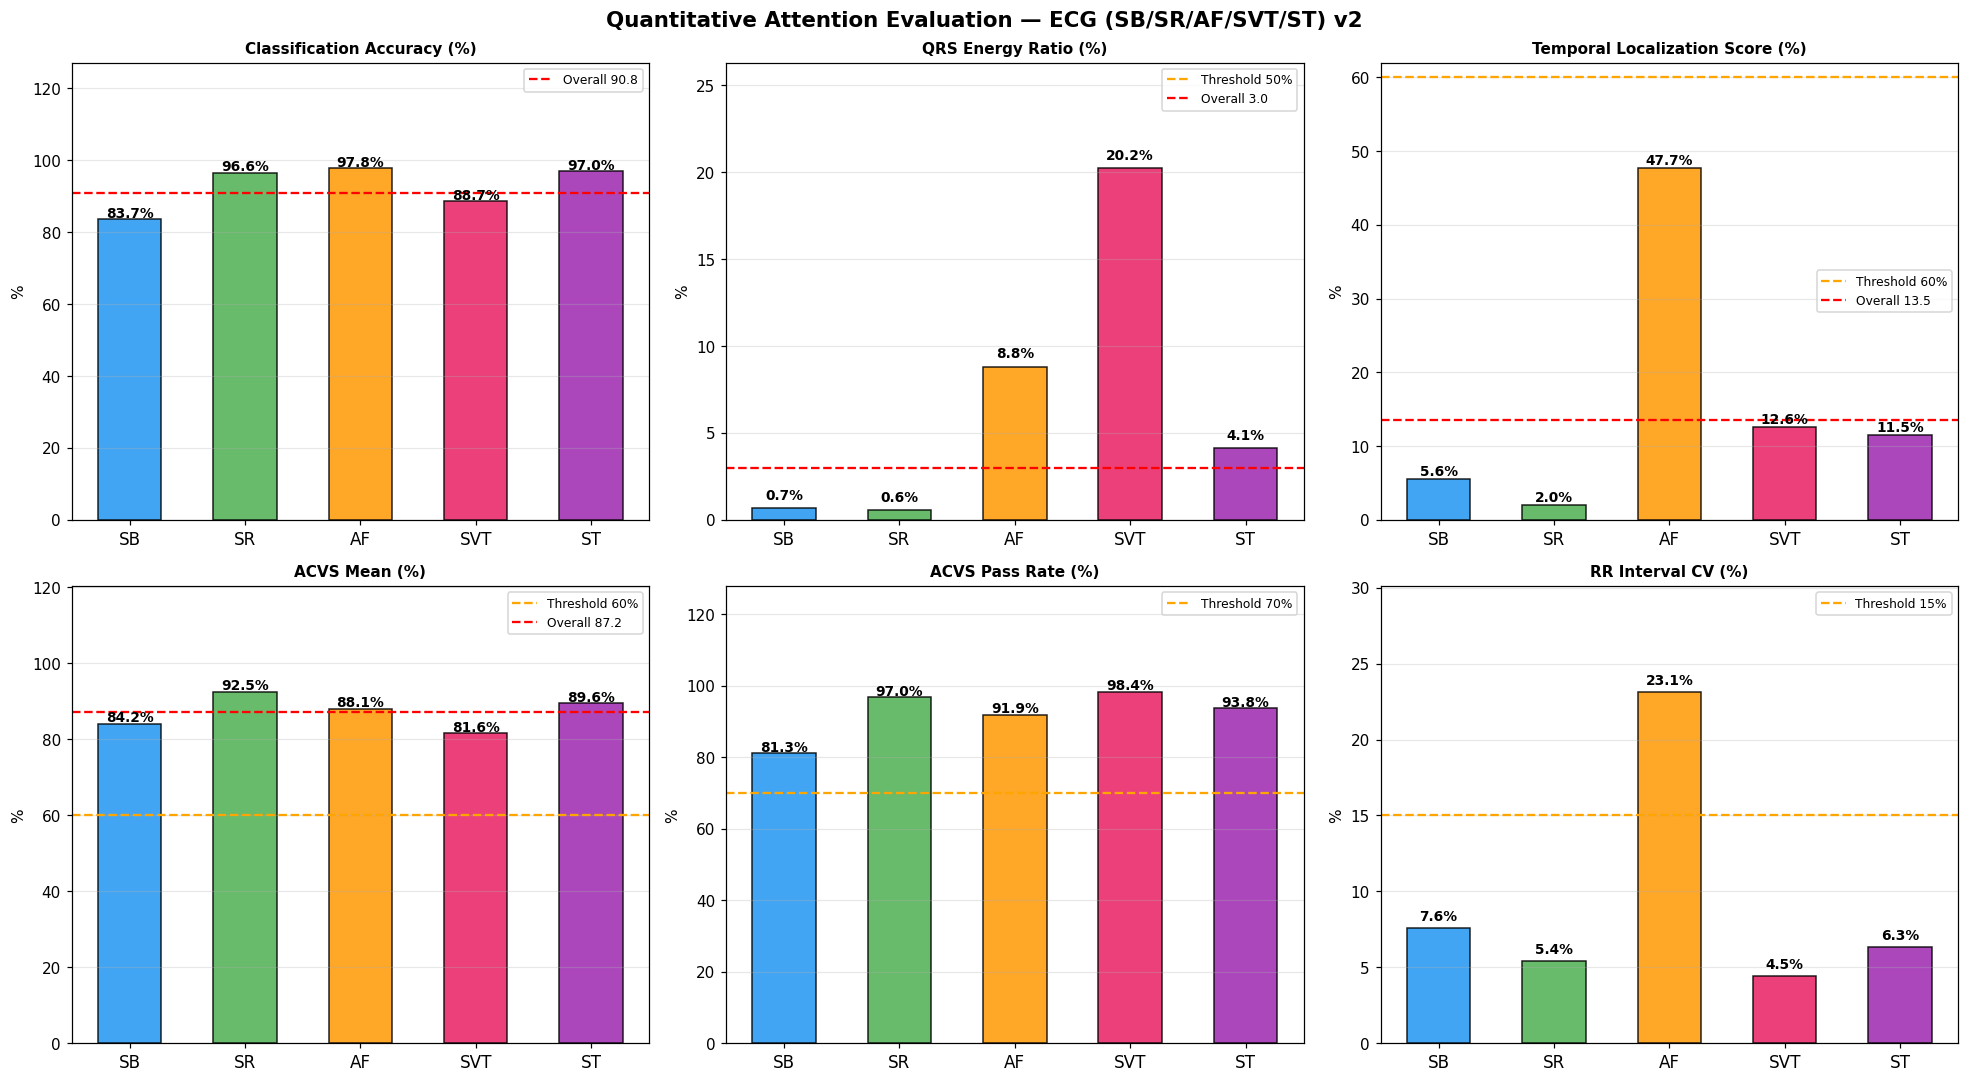

In [6]:
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "data", "processed", "assets", "quantitative_eval_280226")
os.makedirs(OUTPUT_DIR, exist_ok=True)

fig = plot_quantitative_summary(
    summary      = summary,
    target_names = TARGET_NAMES,
    save_path    = os.path.join(OUTPUT_DIR, "summary_4metric.png"),
)

# Hướng dẫn đọc kết quả:
# - Accuracy   : phân loại đúng bao nhiêu %
# - QRS Energy : attention có tập trung vào vùng QRS không (>50% = tốt)
# - TLS        : attention có khớp đặc trưng lâm sàng của từng nhãn không (>60% = tốt)
# - RR-CV      : AF nên cao nhất (nhịp không đều), SR/ST/SVT nên thấp


---
## Cell 6 — Vẽ Chi Tiết 1 Mẫu Bất Kỳ

Thay `SAMPLE_IDX` để xem bất kỳ mẫu nào trong tập test.

In [11]:
from visualize.attention_map import get_attention_weights

SAMPLE_IDX = 0   # <-- thay số này để xem mẫu khác

# Load signal từ file
sig_path   = test_files[SAMPLE_IDX]
signal_np  = np.load(sig_path).astype(np.float32)   # (leads, seq_len)
signal_t   = torch.tensor(signal_np, dtype=torch.float32)

# Lấy attention weights
attn_w = get_attention_weights(model, signal_t)

# Detect R-peaks trên Lead II
r_peaks          = detect_r_peaks(signal_np[LEAD_RPEAK], fs=FS)
_, _, rr_stats   = compute_rr_stats(r_peaks, fs=FS)

# Upsample attention
seq_len = signal_np.shape[1]
attn_up = np.interp(
    np.arange(seq_len),
    np.linspace(0, seq_len - 1, len(attn_w)),
    attn_w
)

# Tính metrics
qrs_ratio, _, _ = compute_attention_energy_in_qrs(attn_w, r_peaks, seq_len, fs=FS)
tls, _, info    = compute_temporal_localization_score(attn_up, r_peaks,
                      TARGET_NAMES[np.argmax(y_test[SAMPLE_IDX])],
                      fs=FS, signal_len=seq_len)

# Nhãn GT và Pred
gt_label   = TARGET_NAMES[np.argmax(y_test[SAMPLE_IDX])]
with torch.no_grad():
    out   = model(signal_t.unsqueeze(0).to(device))
    if isinstance(out, tuple): out = out[0]
    prob  = torch.sigmoid(out).cpu().numpy()[0]
pred_label = TARGET_NAMES[np.argmax(prob)]
pred_conf  = float(prob.max())

print(f'Sample #{SAMPLE_IDX}  |  GT: {gt_label}  |  Pred: {pred_label}  |  Conf: {pred_conf:.3f}')
print(f'R-peaks detected: {len(r_peaks)}')
print(f'QRS Energy Ratio: {qrs_ratio*100:.1f}%')
print(f'TLS Score       : {tls*100:.1f}%  ({info["region_name"]})')
print(f'RR Mean         : {rr_stats.get("rr_mean_ms", "N/A")} ms')
print(f'Heart Rate      : {rr_stats.get("heart_rate", "N/A")} bpm')
print(f'RR-CV           : {rr_stats.get("rr_cv_pct", "N/A")} %')

  output[0] shape: torch.Size([1, 512])
  output[1] shape: torch.Size([1, 157, 1])
  output[0] shape: torch.Size([1, 512])
  output[1] shape: torch.Size([1, 157, 1])
Sample #0  |  GT: SB  |  Pred: SB  |  Conf: 0.894
R-peaks detected: 8
QRS Energy Ratio: 0.0%
TLS Score       : 0.0%  (QRS + Post-T Region)
RR Mean         : 1126.9 ms
Heart Rate      : 53.2 bpm
RR-CV           : 2.5 %


[OK] Lưu: E:\NCKH - 2026\ECG Project\data\processed\assets\quantitative_eval_280226\sample_0_SB.png


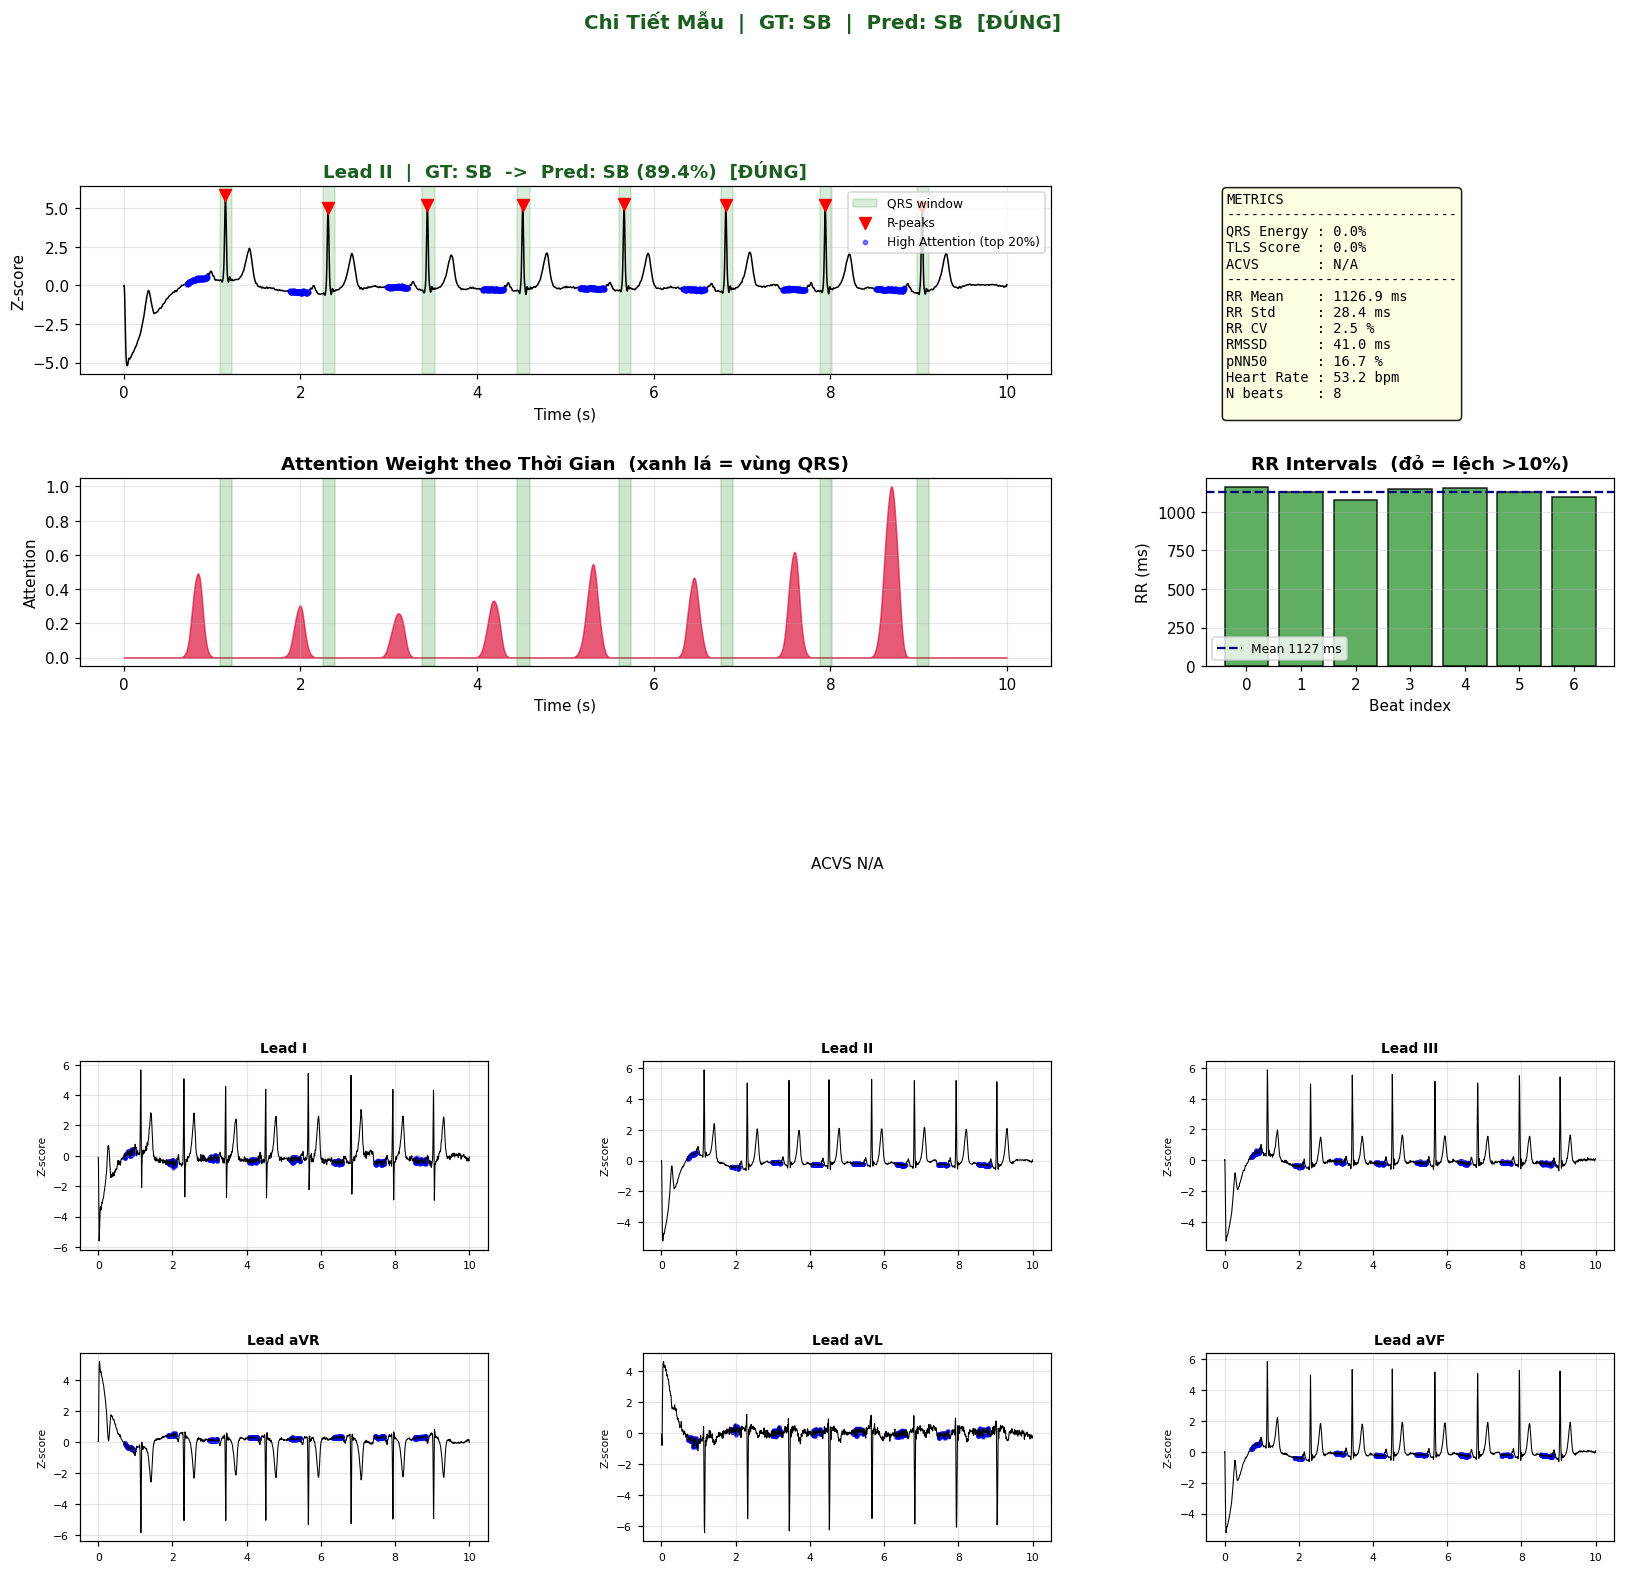

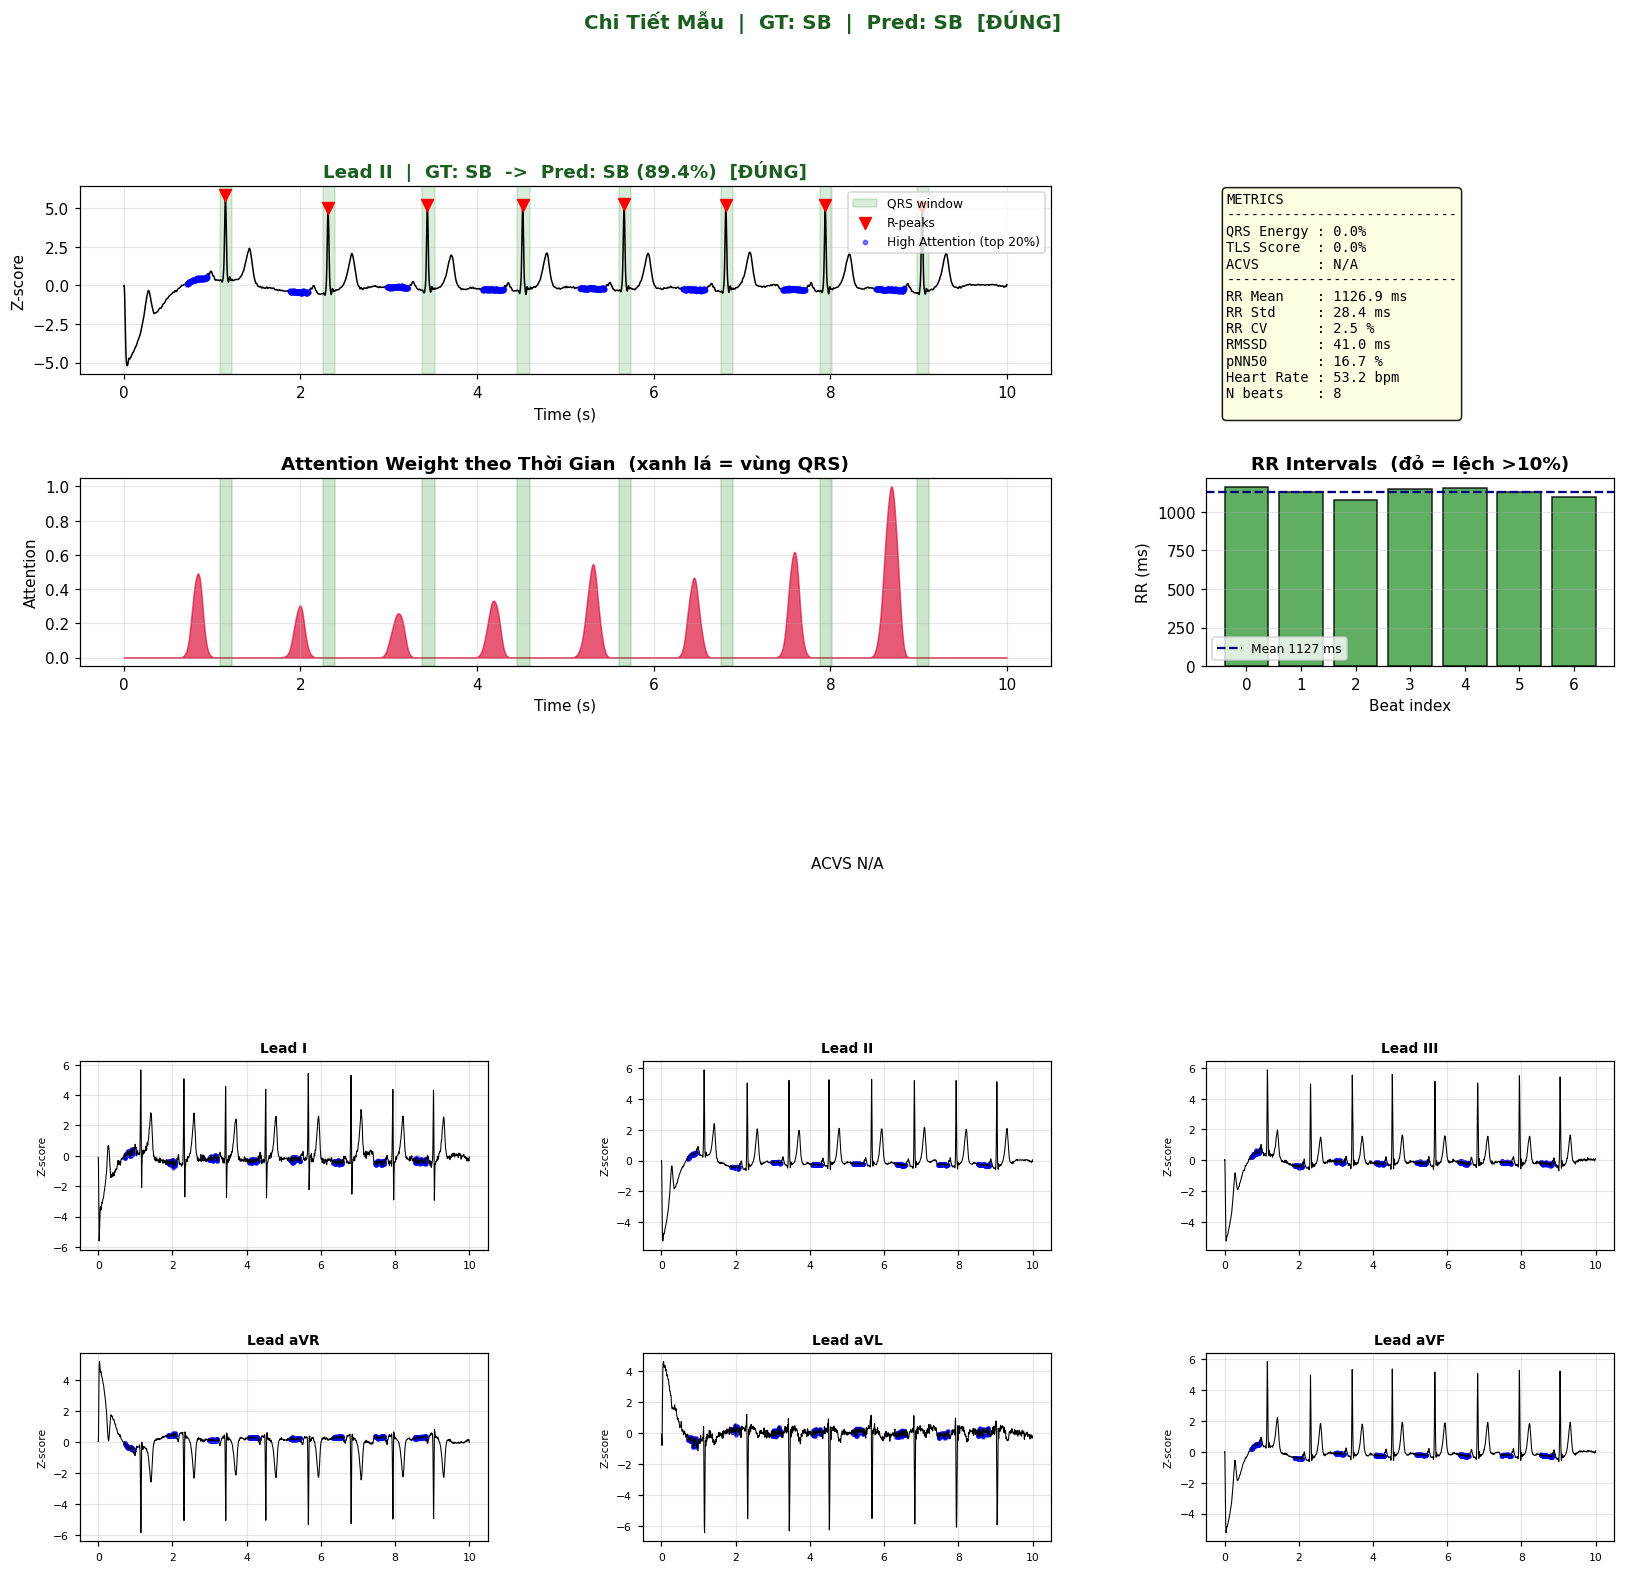

In [12]:
# Vẽ figure đầy đủ
plot_single_sample(
    signal_np        = signal_np,
    attn_weights     = attn_w,
    r_peaks          = r_peaks,
    gt_label         = gt_label,
    pred_label       = pred_label,
    pred_conf        = pred_conf,
    qrs_energy_ratio = qrs_ratio,
    tls              = tls,
    rr_stats         = rr_stats,
    fs               = FS,
    lead_for_rpeak   = LEAD_RPEAK,
    save_path        = os.path.join(OUTPUT_DIR, f'sample_{SAMPLE_IDX}_{gt_label}.png'),
)

---
## Cell 7 — Vẽ Tự Động: 1 Case Đúng + 1 Case Sai Cho Mỗi Nhãn

Hữu ích để xem **model nhầm ở pattern nào** (ví dụ: nhầm AF với SR, hay SVT với ST).

In [ ]:
from visualize.attention_map import get_attention_weights

# ── Tìm 1 case đúng + 1 case sai cho mỗi nhãn ──
def get_representative_cases(all_results, target_names, n_per_class=1):
    cases = {}
    for label in target_names:
        sub_correct = [r for r in all_results if r['gt_label'] == label and r['correct']]
        sub_wrong   = [r for r in all_results if r['gt_label'] == label and not r['correct']]
        cases[label] = {
            'correct': sub_correct[:n_per_class],
            'wrong'  : sub_wrong[:n_per_class],
        }
    return cases


def plot_case(r, test_files, y_test, model, device, fs, lead_rpeak, output_dir, tag):
    idx       = r['sample_idx']
    sig_np    = np.load(test_files[idx]).astype(np.float32)
    sig_t     = torch.tensor(sig_np, dtype=torch.float32)
    attn_w    = get_attention_weights(model, sig_t)
    r_peaks   = detect_r_peaks(sig_np[lead_rpeak], fs=fs)
    _, _, rr  = compute_rr_stats(r_peaks, fs=fs)
    seq_len   = sig_np.shape[1]
    attn_up   = np.interp(np.arange(seq_len),
                          np.linspace(0, seq_len-1, len(attn_w)), attn_w)
    qrs_r, _, _  = compute_attention_energy_in_qrs(attn_w, r_peaks, seq_len, fs=fs)
    tls_v, _, _  = compute_temporal_localization_score(
                       attn_up, r_peaks, r['gt_label'], fs=fs, signal_len=seq_len)
    sp = os.path.join(output_dir, f"{r['gt_label']}_{tag}_idx{idx}.png")
    plot_single_sample(sig_np, attn_w, r_peaks,
                       r['gt_label'], r['pred_label'], r['pred_conf'],
                       qrs_r, tls_v, rr, fs=fs, save_path=sp)


cases = get_representative_cases(all_results, TARGET_NAMES, n_per_class=1)

for label in TARGET_NAMES:
    print(f'\n{'='*50}')
    print(f'  Nhãn: {label}')
    print(f'{'='*50}')

    for case_list, tag in [(cases[label]['correct'], 'DUNG'),
                            (cases[label]['wrong'],   'SAI')]:
        if not case_list:
            print(f'  Không có case {tag} cho {label}')
            continue
        print(f'\n  --- Case {tag} ---')
        plot_case(case_list[0], test_files, y_test, model,
                  device, FS, LEAD_RPEAK, OUTPUT_DIR, tag)

---
## Cell 8 — Lưu Kết Quả

In [ ]:
# Lưu CSV — mỗi dòng là 1 mẫu test
csv_path = os.path.join(OUTPUT_DIR, 'quantitative_results.csv')
save_results_csv(all_results, save_path=csv_path)

# Xem trước vài dòng
import pandas as pd
df = pd.read_csv(csv_path)
print(f'Shape: {df.shape}')
df.head(10)

In [ ]:
# Phân tích nhanh từ CSV
print('Accuracy theo nhãn:')
print(df.groupby('gt_label')['correct'].mean().round(3) * 100)

print('\nQRS Energy Ratio theo nhãn:')
print(df.groupby('gt_label')['qrs_energy_ratio'].mean().round(3) * 100)

print('\nTLS theo nhãn:')
print(df.groupby('gt_label')['tls'].mean().round(3) * 100)

print('\nRR-CV theo nhãn (AF nên cao nhất):')
print(df.groupby('gt_label')['rr_cv_pct'].mean().round(1))

print('\nHeart Rate theo nhãn:')
print(df.groupby('gt_label')['heart_rate'].mean().round(1))

In [ ]:
# Lưu summary dạng text
summary_txt = os.path.join(OUTPUT_DIR, 'summary.txt')
with open(summary_txt, 'w', encoding='utf-8') as f:
    ov = summary['overall']
    f.write('QUANTITATIVE EVALUATION SUMMARY\n')
    f.write('=' * 50 + '\n\n')
    f.write(f"Total samples : {ov['n_samples']}\n")
    f.write(f"Valid samples : {ov['n_valid']}\n")
    f.write(f"Accuracy      : {ov['accuracy_pct']}%\n")
    f.write(f"QRS Energy    : {ov['qrs_energy_mean_pct']}%\n")
    f.write(f"TLS Score     : {ov['tls_mean_pct']}%\n\n")
    f.write(f"{'Label':<8} {'N':>5} {'Acc%':>7} {'QRS%':>7} {'TLS%':>7} {'RR-CV%':>8} {'HR':>8}\n")
    f.write('-' * 50 + '\n')
    for label in TARGET_NAMES:
        if label not in summary: continue
        s = summary[label]
        f.write(f"{label:<8} {s['n_samples']:>5} {s['accuracy_pct']:>7.1f}"
                f" {s['qrs_energy_pct']:>7.1f} {s['tls_pct']:>7.1f}"
                f" {s['rr_cv_mean_pct']:>8.1f} {s['heart_rate_mean_bpm']:>8.1f}\n")
print(f'Saved: {summary_txt}')

---
## Cell 9 — Debug: Kiểm Tra R-Peak Detection

Chạy cell này nếu `n_r_peaks` trong kết quả quá thấp (< 2).  
Thử điều chỉnh tham số `height` và `prominence` của `detect_r_peaks()`.

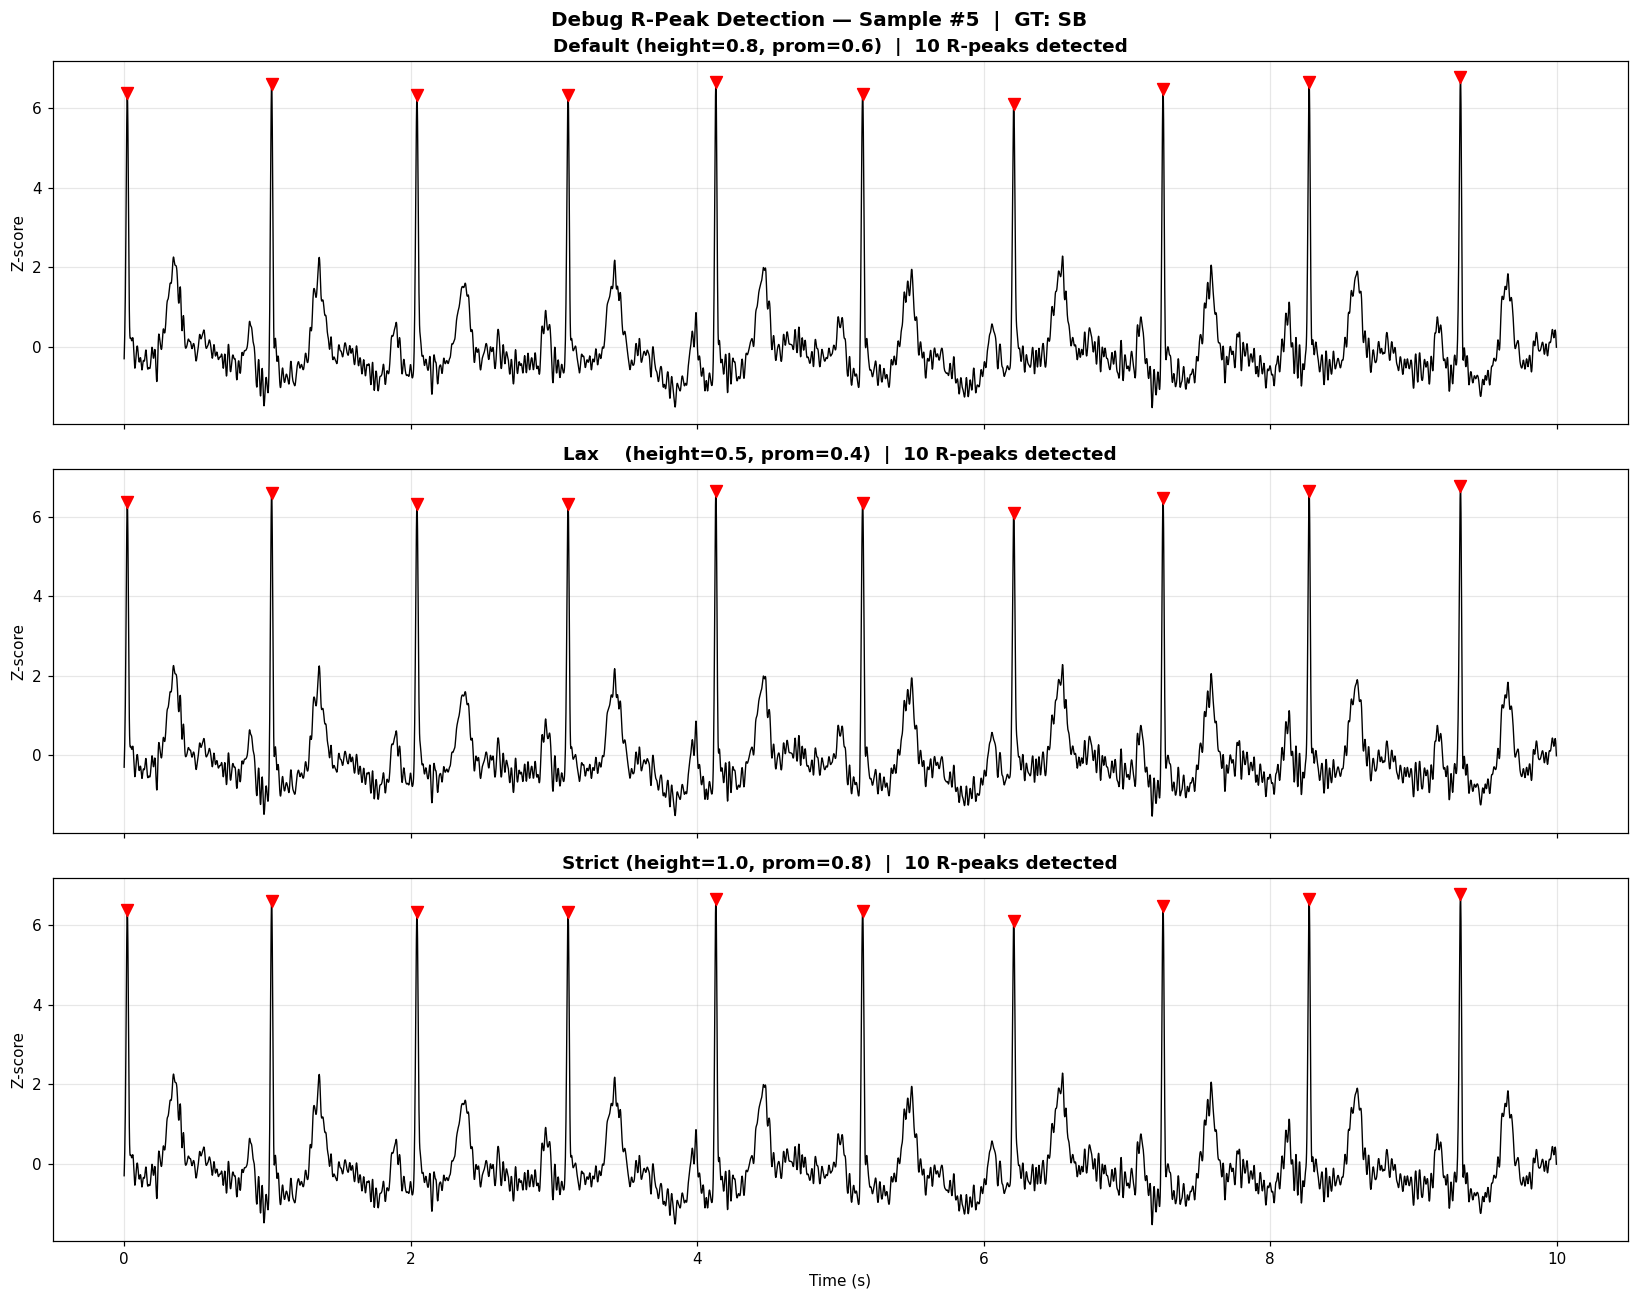


Gợi ý: Nếu tín hiệu của bạn có Z-score thấp hơn 0.8,
hãy giảm height xuống 0.5 trong file ecg_quantitative_eval.py
tại hàm detect_r_peaks(), tham số height=


In [5]:
from scipy.signal import find_peaks

DEBUG_IDX = 5   # <-- thay index mẫu cần debug

sig_debug = np.load(test_files[DEBUG_IDX]).astype(np.float32)
lead_ii   = sig_debug[LEAD_RPEAK]     # Lead II
time_arr  = np.arange(len(lead_ii)) / FS

# Thử các tham số khác nhau
configs = [
    {'height': 0.8,  'prominence': 0.6,  'label': 'Default (height=0.8, prom=0.6)'},
    {'height': 0.5,  'prominence': 0.4,  'label': 'Lax    (height=0.5, prom=0.4)'},
    {'height': 1.0,  'prominence': 0.8,  'label': 'Strict (height=1.0, prom=0.8)'},
]

fig, axes = plt.subplots(len(configs), 1, figsize=(15, 4 * len(configs)), sharex=True)
if len(configs) == 1: axes = [axes]

for ax, cfg in zip(axes, configs):
    peaks, _ = find_peaks(lead_ii,
                          height=cfg['height'],
                          distance=int(FS * 0.45),
                          prominence=cfg['prominence'])
    ax.plot(time_arr, lead_ii, 'k-', lw=0.9)
    ax.scatter(time_arr[peaks], lead_ii[peaks], color='red', s=60, zorder=5, marker='v')
    ax.set_title(f"{cfg['label']}  |  {len(peaks)} R-peaks detected",
                 fontweight='bold')
    ax.set_ylabel('Z-score'); ax.grid(alpha=0.3)

axes[-1].set_xlabel('Time (s)')
plt.suptitle(f'Debug R-Peak Detection — Sample #{DEBUG_IDX}  |  GT: {TARGET_NAMES[np.argmax(y_test[DEBUG_IDX])]}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nGợi ý: Nếu tín hiệu của bạn có Z-score thấp hơn 0.8,')
print('hãy giảm height xuống 0.5 trong file ecg_quantitative_eval.py')
print('tại hàm detect_r_peaks(), tham số height=')

---
## Cell 10 — Chạy Nhanh 100 Mẫu Đầu (Test Thử)

Dùng để kiểm tra pipeline trước khi chạy toàn bộ tập test.

In [6]:
# Chạy thử 100 mẫu đầu để kiểm tra nhanh
results_quick, summary_quick = evaluate_attention_quantitative(
    model          = model,
    test_loader    = test_loader,
    y_test         = y_test,
    target_names   = TARGET_NAMES,
    device         = device,
    fs             = FS,
    lead_for_rpeak = LEAD_RPEAK,
    n_samples_max  = 100,    # chỉ 100 mẫu đầu
    verbose        = True,
)

print(f"\nKiểm tra n_r_peaks:")
n_peaks_arr = [r['n_r_peaks'] for r in results_quick]
print(f"  Mean : {np.mean(n_peaks_arr):.1f}")
print(f"  Min  : {np.min(n_peaks_arr)}")
print(f"  Max  : {np.max(n_peaks_arr)}")
no_peak = sum(1 for n in n_peaks_arr if n < 2)
print(f"  Mẫu không đủ R-peaks (<2): {no_peak} / {len(results_quick)}")
if no_peak > len(results_quick) * 0.2:
    print("  ⚠️  Quá nhiều mẫu không có R-peak → Hãy chạy Cell 9 để debug")

Đánh giá định lượng:   0%|                                                                      | 0/70 [00:00<?, ?it/s]

  output[0] shape: torch.Size([64, 512])
  output[1] shape: torch.Size([64, 157, 1])
  output[0] shape: torch.Size([1, 512])
  output[1] shape: torch.Size([1, 157, 1])
  output[0] shape: torch.Size([1, 512])
  output[1] shape: torch.Size([1, 157, 1])
  output[0] shape: torch.Size([1, 512])
  output[1] shape: torch.Size([1, 157, 1])
  output[0] shape: torch.Size([1, 512])
  output[1] shape: torch.Size([1, 157, 1])
  output[0] shape: torch.Size([1, 512])
  output[1] shape: torch.Size([1, 157, 1])
  output[0] shape: torch.Size([1, 512])
  output[1] shape: torch.Size([1, 157, 1])
  output[0] shape: torch.Size([1, 512])
  output[1] shape: torch.Size([1, 157, 1])
  output[0] shape: torch.Size([1, 512])
  output[1] shape: torch.Size([1, 157, 1])
  output[0] shape: torch.Size([1, 512])
  output[1] shape: torch.Size([1, 157, 1])
  output[0] shape: torch.Size([1, 512])
  output[1] shape: torch.Size([1, 157, 1])
  output[0] shape: torch.Size([1, 512])
  output[1] shape: torch.Size([1, 157, 1])
  

Đánh giá định lượng:   1%|▉                                                             | 1/70 [00:02<03:16,  2.85s/it]

  output[0] shape: torch.Size([1, 512])
  output[1] shape: torch.Size([1, 157, 1])
  output[0] shape: torch.Size([1, 512])
  output[1] shape: torch.Size([1, 157, 1])
  output[0] shape: torch.Size([1, 512])
  output[1] shape: torch.Size([1, 157, 1])
  output[0] shape: torch.Size([1, 512])
  output[1] shape: torch.Size([1, 157, 1])
  output[0] shape: torch.Size([64, 512])
  output[1] shape: torch.Size([64, 157, 1])
  output[0] shape: torch.Size([1, 512])
  output[1] shape: torch.Size([1, 157, 1])
  output[0] shape: torch.Size([1, 512])
  output[1] shape: torch.Size([1, 157, 1])
  output[0] shape: torch.Size([1, 512])
  output[1] shape: torch.Size([1, 157, 1])
  output[0] shape: torch.Size([1, 512])
  output[1] shape: torch.Size([1, 157, 1])
  output[0] shape: torch.Size([1, 512])
  output[1] shape: torch.Size([1, 157, 1])
  output[0] shape: torch.Size([1, 512])
  output[1] shape: torch.Size([1, 157, 1])
  output[0] shape: torch.Size([1, 512])
  output[1] shape: torch.Size([1, 157, 1])
  

Đánh giá định lượng:   1%|▉                                                             | 1/70 [00:04<05:32,  4.82s/it]

  output[0] shape: torch.Size([1, 512])
  output[1] shape: torch.Size([1, 157, 1])
  output[0] shape: torch.Size([1, 512])
  output[1] shape: torch.Size([1, 157, 1])
  output[0] shape: torch.Size([1, 512])
  output[1] shape: torch.Size([1, 157, 1])
  output[0] shape: torch.Size([1, 512])
  output[1] shape: torch.Size([1, 157, 1])

  KẾT QUẢ ĐÁNH GIÁ ĐỊNH LƯỢNG ATTENTION MAP (v2 + ACVS)
  Tổng mẫu   : 100  (hợp lệ: 100)
  Accuracy   : 82.0%
  QRS Energy : 2.65%   (>50% là tốt)
  TLS Score  : 17.12%   (>60% là tốt)
  ACVS Mean  : 0.8185   (>0.60 là tốt)

  Label       N    Acc%    QRS%    TLS%    ACVS   Pass%   RR-CV%   RMSSD
  ----------------------------------------------------------------------
  SB         54    70.4     1.1    10.4  0.7833    81.5     10.0   144.4
  SR         13    92.3     1.1     5.6  0.8192    84.6      8.3    75.2
  AF         17   100.0     6.0    50.4  0.9088    94.1     22.9   178.3
  ST         16    93.8     5.7    13.7  0.8406    93.8     11.1    83.3

  

In [7]:
# Lấy cả 2 — upsampled (5000) và raw (157)
attn_up, attn_raw = get_attention_weights(model, signal, 
                                           upsample_method='gaussian', 
                                           return_raw=True)

# Vẽ với panel raw attention phía dưới
fig = plot_attention_dots(signal, 
                          attn_weights=attn_up, 
                          attn_weights_raw=attn_raw,   # ← mới
                          label_true="AF", 
                          label_pred="AF")

# So sánh 3 methods (chạy 1 lần để chọn method tốt nhất cho dataset)
fig_cmp = plot_attention_comparison(signal, model, fs=500)

NameError: name 'get_attention_weights' is not defined